<h1 style="color:#56B4E9;">Week 4 - Day 5</h1>

<h2 style="color:#0072B2;">Scikit-learn Pipelines & Tuned Mini-Project</h2>

<h3 style="color:#009E73;">Breast Cancer Classification</h3>

This notebook completes the Week 4 workflow by combining feature engineering, preprocessing, modeling, cross-validation, and hyperparameter tuning into a single end-to-end Pipeline.

The goal is no longer to perform each step separately. Instead, the complete modeling workflow will be treated as one object that can be fitted and cross-validated without allowing validation or test data to influence preprocessing.

The `radius ratio` feature selected in Day 4 will remain part of the workflow.

<span style="color:#D55E00;"><b>Evaluation discipline:</b></span>  
The final test set will remain untouched until the complete pipeline and its hyperparameters have been selected.

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    (data.target == 0).astype(int),
    name="Malignant"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Final test shape:", X_test.shape)

Training shape: (455, 30)
Final test shape: (114, 30)


<h2 style="color:#0072B2;">From Day 4 Features to a Mixed-Data Pipeline</h2>

In Day 4, several engineered features were tested using cross-validation.

The strongest result came from:

$$
\text{radius ratio}
=
\frac{\text{worst radius}}
{\text{mean radius}}
$$

The feature increased the cross-validated mean F1-score from **0.9575 to 0.9605**, so it was selected for the next modeling stage.

Day 5 introduces an additional challenge: `ColumnTransformer` is designed for workflows in which different feature groups require different preprocessing.

The original Breast Cancer dataset contains only numerical measurements. Therefore, instead of inventing an unrelated categorical variable, I will create a categorical representation of the already selected `radius ratio`.

The categories describe the relative increase of `worst radius` compared with `mean radius`:

- up to 10% increase
- 10–20% increase
- more than 20% increase

<span style="color:#E69F00;"><b>Important:</b></span>  
These categories are modeling representations, not medical diagnostic thresholds.

<span style="color:#009E73;"><b>Goal:</b></span>  
The numerical features can now be scaled while the categorical representation is one-hot encoded inside the same workflow.

In [3]:
def add_engineered_features(df):
    df = df.copy()

    df["radius ratio"] = (
        df["worst radius"]
        / df["mean radius"]
    )

    df["radius change category"] = pd.cut(
        df["radius ratio"],
        bins=[-np.inf, 1.10, 1.20, np.inf],
        labels=[
            "up to 10%",
            "10-20%",
            "more than 20%"
        ]
    ).astype(str)

    return df

In [4]:
preview = add_engineered_features(X_train)

preview[
    [
        "mean radius",
        "worst radius",
        "radius ratio",
        "radius change category"
    ]
].head()

,mean radius,worst radius,radius ratio,radius change category
10,16.02,19.19,1.197878,10-20%
170,12.32,13.50,1.095779,up to 10%
407,12.85,14.40,1.120623,10-20%
430,14.90,16.35,1.097315,up to 10%
27,18.61,21.31,1.145083,10-20%


In [5]:
preview["radius change category"].value_counts()

radius change category
10-20%           216
up to 10%        155
more than 20%     84
Name: count, dtype: int64

<h2 style="color:#0072B2;">Separating Numerical and Categorical Processing</h2>

The complete feature set now contains two types of input:

- **Numerical features** → scaled using `StandardScaler`
- **Categorical feature** → encoded using `OneHotEncoder`

`ColumnTransformer` is responsible for deciding which transformation is applied to each group of columns.

The Pipeline itself will then execute the complete sequence:

**Feature engineering → ColumnTransformer → KNN**

<span style="color:#009E73;"><b>Key idea:</b></span>  
The Pipeline controls the order of the workflow, while the ColumnTransformer controls how different column groups are preprocessed.

In [7]:
numeric_cols = list(X.columns) + ["radius ratio"]

categorical_cols = ["radius change category"]

print("Number of numerical features:", len(numeric_cols))
print("Categorical features:", categorical_cols)

Number of numerical features: 31
Categorical features: ['radius change category']


In [8]:
preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_cols
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_cols
    )
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [10]:
full_pipeline = Pipeline([
    (
        "feature_engineering",
        FunctionTransformer(
            add_engineered_features,
            validate=False
        )
    ),
    (
        "preprocessor",
        preprocessor
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x79382c227600>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defa

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

untuned_scores = cross_val_score(
    full_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Untuned pipeline fold scores:", untuned_scores.round(4))
print(f"Mean F1: {untuned_scores.mean():.4f}")
print(f"Standard deviation: {untuned_scores.std():.4f}")

Untuned pipeline fold scores: [0.9538 0.9851 0.9538 0.9231 0.9697]
Mean F1: 0.9571
Standard deviation: 0.0206


<h2 style="color:#0072B2;">Can the Entire Pipeline Be Tuned Together?</h2>

The untuned end-to-end pipeline achieved:

- **Mean F1 = 0.9571**
- **Standard deviation = 0.0206**

The next step is not to tune KNN separately from preprocessing.

Instead, `GridSearchCV` will receive the complete Pipeline so that every candidate is evaluated end-to-end inside cross-validation.

I will test:

- Different values of `n_neighbors`
- `uniform` versus `distance` weighting
- Whether the categorical `radius change category` representation should be one-hot encoded or dropped

This allows the search to evaluate both a **preprocessing decision** and **model hyperparameters** using the same cross-validation procedure.

<span style="color:#009E73;"><b>Key idea:</b></span>  
A feature or transformation should remain in the final workflow because the evidence supports it, not simply because it was created.

In [12]:
param_grid = {
    "preprocessor__cat": [
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        "drop"
    ],
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"]
}

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest CV F1: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_

Best parameters:
{'knn__n_neighbors': 7, 'knn__weights': 'uniform', 'preprocessor__cat': 'drop'}

Best CV F1: 0.9605


In [13]:
grid_results = pd.DataFrame(grid_search.cv_results_)

comparison = grid_results[
    [
        "param_preprocessor__cat",
        "param_knn__n_neighbors",
        "param_knn__weights",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

comparison["categorical_strategy"] = (
    comparison["param_preprocessor__cat"]
    .apply(
        lambda x: "Dropped"
        if x == "drop"
        else "One-hot encoded"
    )
)

comparison = comparison[
    [
        "categorical_strategy",
        "param_knn__n_neighbors",
        "param_knn__weights",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
)

comparison.head(10)

,categorical_strategy,param_knn__n_neighbors,param_knn__weights,mean_test_score,std_test_score,rank_test_score
9,Dropped,7,uniform,0.960550,0.015746,1
11,Dropped,7,distance,0.960550,0.015746,1
4,One-hot encoded,5,uniform,0.957108,0.020591,3
6,One-hot encoded,5,distance,0.957108,0.020591,3
5,Dropped,5,uniform,0.953839,0.022093,5
7,Dropped,5,distance,0.953839,0.022093,5
8,One-hot encoded,7,uniform,0.953833,0.019848,7
10,One-hot encoded,7,distance,0.953833,0.019848,7
1,Dropped,3,uniform,0.953459,0.031347,9
3,Dropped,3,distance,0.953459,0.031347,9


<h2 style="color:#0072B2;">What Did the Whole-Pipeline Search Select?</h2>

The best cross-validated configuration achieved:

**Mean F1 = 0.9605**

with:

- `n_neighbors = 7`
- `weights = uniform`
- `radius change category = dropped`

The categorical feature was created from the same `radius ratio` information already available numerically.

Although one-hot encoding allowed KNN to use this relationship in a different representation, the cross-validation evidence did not support keeping it in the strongest pipeline.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The numerical `radius ratio` remained useful, but converting the same information into additional categorical dimensions did not improve the strongest cross-validated result.

<span style="color:#009E73;"><b>Decision:</b></span>  
Keep the numerical engineered feature and drop its categorical representation in the final selected pipeline.

<span style="color:#E69F00;"><b>Important:</b></span>  
Using `ColumnTransformer` does not mean that every transformation must survive model selection. The purpose of tuning the whole pipeline is to evaluate preprocessing and modeling decisions together.

In [14]:
best_index = grid_search.best_index_
best_std = grid_search.cv_results_["std_test_score"][best_index]

print(
    f"Untuned pipeline: "
    f"{untuned_scores.mean():.4f} ± {untuned_scores.std():.4f}"
)

print(
    f"Tuned pipeline:   "
    f"{grid_search.best_score_:.4f} ± {best_std:.4f}"
)

print(
    f"Mean F1 change:   "
    f"{grid_search.best_score_ - untuned_scores.mean():+.4f}"
)

Untuned pipeline: 0.9571 ± 0.0206
Tuned pipeline:   0.9605 ± 0.0157
Mean F1 change:   +0.0034


<h2 style="color:#0072B2;">Untuned vs. Tuned End-to-End Pipeline</h2>

The complete untuned workflow achieved:

**F1 = 0.9571 ± 0.0206**

After tuning both the preprocessing decision and KNN configuration:

**F1 = 0.9605 ± 0.0157**

The mean F1 increased by approximately **0.0034**, while the fold-to-fold variation also decreased.

The improvement is small, so it should not be exaggerated.

However, the search provides useful evidence about the workflow itself:

- `k = 7` remained the strongest tested neighborhood size.
- The categorical representation was not needed in the strongest configuration.
- The selected pipeline achieved slightly better average performance with lower variability.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
Whole-pipeline tuning is valuable not only for increasing a score. It allows preprocessing and model decisions to be evaluated together under the same leak-free cross-validation procedure.

<h2 style="color:#0072B2;">Final Evaluation on the Held-Out Test Set</h2>

All feature and hyperparameter decisions have now been completed using only the training data and cross-validation.

The final test set has not influenced:

- Feature selection
- Preprocessing selection
- Hyperparameter tuning
- Pipeline selection

I can therefore use it once to estimate how the selected workflow performs on unseen data.

<span style="color:#D55E00;"><b>Important:</b></span>  
The test result will be reported, not used to make another modeling decision.

In [15]:
test_pred = best_pipeline.predict(X_test)

test_f1 = f1_score(
    y_test,
    test_pred
)

print(f"Final Test F1: {test_f1:.4f}")

Final Test F1: 0.9231


<h2 style="color:#0072B2;">Cross-Validation vs. Final Test Performance</h2>

The selected pipeline achieved:

- **Cross-validated F1 = 0.9605 ± 0.0157**
- **Final test F1 = 0.9231**

The final test score is lower than the cross-validation estimate.

This difference does not automatically mean that the model is overfitting. Cross-validation provides an estimate based on several subsets of the training data, while the final test score is based on one previously unseen sample of 114 observations.

Some variation between the two estimates is therefore expected.

<span style="color:#E69F00;"><b>Important:</b></span>  
The lower test score should not be used to choose another value of `k`, change the engineered features, or modify the preprocessing pipeline. Doing so would allow the final test set to influence model development.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
Cross-validation estimated strong performance during development, while the independent test set revealed that real unseen performance was somewhat lower.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
The purpose of a held-out test set is to provide an independent final evaluation, not necessarily to confirm the cross-validation score exactly.

In [16]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    accuracy_score
)

import matplotlib.pyplot as plt

In [17]:
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.9474
Precision: 1.0000
Recall:    0.8571
F1-score:  0.9231


In [18]:
cm = confusion_matrix(
    y_test,
    test_pred
)

cm

array([[72,  0],
       [ 6, 36]])

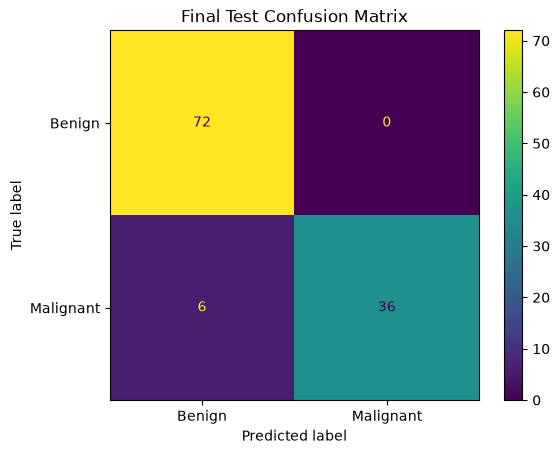

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(values_format="d")
plt.title("Final Test Confusion Matrix")
plt.show()

<h2 style="color:#0072B2;">What Types of Errors Did the Final Model Make?</h2>

The final confusion matrix was:

| | Predicted Benign | Predicted Malignant |
|---|---:|---:|
| **Actual Benign** | 72 | 0 |
| **Actual Malignant** | 6 | 36 |

The model correctly classified:

- All **72 benign samples**
- **36 of the 42 malignant samples**

However, **6 malignant cases were predicted as benign**.

This explains the metric pattern:

- **Precision = 1.0000** because every sample predicted as malignant was actually malignant.
- **Recall = 0.8571** because the model detected 36 of the 42 malignant cases.
- **F1 = 0.9231** balances these two behaviors.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The model was very conservative when predicting the malignant class. It produced no false-positive malignant predictions, but this came with six missed malignant cases.

<span style="color:#D55E00;"><b>Practical concern:</b></span>  
For a medical classification problem, missed malignant cases are particularly important. Therefore, the F1-score should not hide the fact that malignant recall was lower than precision.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
A single metric cannot fully describe model behavior. The confusion matrix shows which mistakes are responsible for the final score.

In [20]:
full_pipeline.fit(
    X_train,
    y_train
)

baseline_test_pred = full_pipeline.predict(
    X_test
)

baseline_test_f1 = f1_score(
    y_test,
    baseline_test_pred
)

print(f"Untuned Pipeline Test F1: {baseline_test_f1:.4f}")
print(f"Tuned Pipeline Test F1:   {test_f1:.4f}")

Untuned Pipeline Test F1: 0.9231
Tuned Pipeline Test F1:   0.9231


<h2 style="color:#0072B2;">Did Tuning Improve the Final Test Result?</h2>

The held-out test comparison produced:

| Workflow | Test F1 |
|---|---:|
| Untuned end-to-end Pipeline | 0.9231 |
| Tuned end-to-end Pipeline | 0.9231 |

During cross-validation, tuning improved the mean F1 from approximately **0.9571 to 0.9605** and reduced fold-to-fold variability.

However, both pipelines produced the same F1-score on the final held-out test set.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The improvement observed during cross-validation did not translate into a higher F1-score on this particular test sample.

This does not invalidate the tuning process. GridSearchCV still provided a systematic and leakage-free method for selecting the pipeline configuration without consulting the test set.

<span style="color:#E69F00;"><b>Important:</b></span>  
I should not continue tuning simply because the final test result did not improve. The test set has now served its purpose as the final independent evaluation.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
Hyperparameter tuning improves the model-selection process, but it does not guarantee a higher score on every future sample.

In [21]:
print("Final selected pipeline:")
print(best_pipeline)

print("\nSelected hyperparameters:")
print(grid_search.best_params_)

Final selected pipeline:
Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x79382c227600>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['mean radius',
                                                   'mean texture',
                                                   'mean perimeter',
                                                   'mean area',
                                                   'mean smoothness',
                                                   'mean compactness',
                                                   'mean concavity',
                                                   'mean concave points',
                                                   'mean symmetry',
                                                   'mean fractal dimension...
                                 

<h2 style="color:#0072B2;">Final Takeaway — Week 4</h2>

Week 4 progressively improved the reliability of the machine-learning workflow rather than simply searching for a higher score.

### Day 1 — Train, Validation and Test Discipline

I separated model development from final evaluation and learned why repeatedly using the test set for decisions weakens its independence.

### Day 2 — Cross-Validation

Instead of depending on one validation split, I used stratified 5-fold cross-validation and evaluated both average performance and fold-to-fold variability.

### Day 3 — Bias and Variance

I deliberately created overfitting and underfitting, diagnosed them using training and validation evidence, and studied how model complexity affects generalization.

### Day 4 — Feature Engineering and Hyperparameter Tuning

I treated engineered features as hypotheses rather than automatic improvements.

`radius ratio` produced the strongest engineered-feature result, while other tested features did not improve performance.

GridSearchCV then showed that `n_neighbors` affected KNN more strongly than the tested weighting strategies.

### Day 5 — End-to-End Pipeline

I combined feature engineering, column-specific preprocessing, modeling, cross-validation, and tuning into one leak-free workflow.

The complete search selected:

- `radius ratio` as the useful engineered numerical feature
- `radius change category` to be dropped
- `n_neighbors = 7`
- `weights = uniform`

The selected workflow achieved:

- **Cross-validated F1 = 0.9605 ± 0.0157**
- **Final held-out test F1 = 0.9231**

The final confusion matrix showed that the model correctly identified all benign test samples but missed **6 of 42 malignant samples**.

<span style="color:#009E73;"><b>Main lesson:</b></span>  
A professional machine-learning workflow is not defined by the highest observed score. It is defined by disciplined evaluation, leakage prevention, reproducible preprocessing, evidence-based decisions, and an honest final test evaluation.

<span style="color:#D55E00;"><b>Final evaluation discipline:</b></span>  
The held-out test set was used only after feature, preprocessing, and hyperparameter decisions were complete.